# Example 1 — Gaussian terminal condition in $d=2$: tuned detailed house $\to$ flower

This version goes back to the **156-particle detailed house/flower geometry** and uses a much tighter
parameter choice so the terminal match is visibly sharper.

The main change is to use the explicit **Euclidean Gaussian bridge drift** instead of the wrapped image-sum drift.
For this example both shapes stay well inside $[0,1)^2$, so the universal-cover formula gives a cleaner
endpoint than the wrapped approximation.

Tuned settings used below:

- `drift_mode = "euclidean"`
- `lambda_ = 5e8`
- `horizon = 5e-7`
- `step_size = horizon / 300`
- `seed = 105`

On this tuned run the final weighted mean periodic distance is about **9.5e-4**.

In [8]:
import numpy as np
import sys
from pathlib import Path
from scipy.optimize import linear_sum_assignment

search_roots = []
cwd = Path.cwd().resolve()
search_roots.append(cwd)
search_roots.extend(cwd.parents)
search_roots.append(Path("/mnt/data").resolve())

ROOT = None
for candidate in search_roots:
    if (candidate / "wasserstein_conditioning_algorithms.py").exists():
        ROOT = candidate
        break
if ROOT is None:
    raise FileNotFoundError("Could not locate wasserstein_conditioning_algorithms.py")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from wasserstein_conditioning_algorithms import (
    simulate_gaussian_terminal_em,
    shortest_periodic_displacement,
)

np.set_printoptions(precision=3, suppress=True)

In [9]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio

pio.renderers.default = "notebook"

def line_trace(points, name, color="rgba(80,80,80,0.55)", dash="dot", close=False, showlegend=True, marker_size=4, mode="lines"):
    pts = np.asarray(points, dtype=float)
    if close:
        pts = np.vstack([pts, pts[0]])
    return go.Scatter(
        x=pts[:, 0],
        y=pts[:, 1],
        mode=mode,
        name=name,
        line=dict(color=color, dash=dash),
        marker=dict(size=marker_size, color=color),
        opacity=0.8,
        showlegend=showlegend,
    )

def center_trace(points, name, color="rgba(50,50,50,0.9)", symbol="x", size=10, showlegend=True):
    pts = np.asarray(points, dtype=float)
    return go.Scatter(
        x=pts[:, 0],
        y=pts[:, 1],
        mode="markers",
        name=name,
        marker=dict(symbol=symbol, size=size, color=color, line=dict(color=color, width=1)),
        showlegend=showlegend,
    )

def time_label(t, horizon):
    horizon = float(horizon)
    normalized = 0.0 if horizon == 0.0 else float(t) / horizon
    return f"t/T = {normalized:.3f} (t = {t:.2e})"

def make_particle_animation(
    positions,
    times,
    masses,
    title,
    static_traces=None,
    marker_size=10,
    x_range=(0.0, 1.0),
    y_range=(0.0, 1.0),
):
    static_traces = list(static_traces or [])
    hover_text = [f"particle {i}<br>mass = {m:.5f}" for i, m in enumerate(masses)]
    horizon = float(times[-1])

    particle_trace = go.Scatter(
        x=positions[0, :, 0],
        y=positions[0, :, 1],
        mode="markers",
        name="conditioned particles",
        marker=dict(
            size=marker_size,
            color=masses,
            colorscale="Viridis",
            cmin=float(np.min(masses)),
            cmax=float(np.max(masses)),
            showscale=True,
            colorbar=dict(title="mass"),
            line=dict(color="black", width=0.6),
        ),
        text=hover_text,
        hovertemplate="%{text}<br>x=%{x:.3f}<br>y=%{y:.3f}<extra></extra>",
    )

    fig = go.Figure(data=[*static_traces, particle_trace])
    particle_index = len(static_traces)

    frames = []
    for k, (t, pos) in enumerate(zip(times, positions)):
        frames.append(
            go.Frame(
                data=[go.Scatter(x=pos[:, 0], y=pos[:, 1], text=hover_text)],
                traces=[particle_index],
                name=str(k),
                layout=go.Layout(title_text=f"{title}<br><sup>{time_label(t, horizon)}</sup>"),
            )
        )
    fig.frames = frames

    slider_steps = [
        dict(
            method="animate",
            args=[[str(k)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
            label=f"{(t / horizon):.2f}",
        )
        for k, t in enumerate(times)
    ]

    fig.update_layout(
        title=f"{title}<br><sup>{time_label(times[0], horizon)}</sup>",
        width=840,
        height=760,
        template="simple_white",
        xaxis=dict(range=list(x_range), title="x", scaleanchor="y", scaleratio=1),
        yaxis=dict(range=list(y_range), title="y"),
        legend=dict(x=0.01, y=0.99),
        sliders=[
            dict(
                active=0,
                currentvalue={"prefix": "normalized time t/T = "},
                pad={"t": 20},
                steps=slider_steps,
                x=0.10,
                y=-0.07,
                len=0.82,
            )
        ],
        updatemenus=[
            dict(
                type="buttons",
                direction="left",
                showactive=False,
                x=0.10,
                y=1.12,
                buttons=[
                    dict(label="Play", method="animate", args=[None, {"frame": {"duration": 80, "redraw": True}, "transition": {"duration": 0}, "fromcurrent": True}]),
                    dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "transition": {"duration": 0}, "mode": "immediate"}]),
                ],
            )
        ],
    )
    return fig

In [10]:
def sample_line(p0, p1, n, endpoint=False):
    p0 = np.asarray(p0, dtype=float)
    p1 = np.asarray(p1, dtype=float)
    t = np.linspace(0.0, 1.0, n, endpoint=endpoint)[:, None]
    return p0 + t * (p1 - p0)

def sample_polyline(vertices, n, close=False):
    pts = np.asarray(vertices, dtype=float)
    if close:
        pts = np.vstack([pts, pts[0]])
    segs = pts[1:] - pts[:-1]
    lengths = np.linalg.norm(segs, axis=1)
    cumulative = np.concatenate([[0.0], np.cumsum(lengths)])
    total = cumulative[-1]
    if total <= 0.0:
        raise ValueError("polyline has zero total length")

    samples = np.linspace(0.0, total, n, endpoint=False)
    out = np.empty((n, 2), dtype=float)
    seg_idx = 0
    for i, s in enumerate(samples):
        while seg_idx + 1 < len(cumulative) - 1 and s >= cumulative[seg_idx + 1]:
            seg_idx += 1
        local = 0.0 if lengths[seg_idx] == 0.0 else (s - cumulative[seg_idx]) / lengths[seg_idx]
        out[i] = pts[seg_idx] + local * segs[seg_idx]
    return out

def sample_circle(center, radius, n, start_angle=0.0):
    center = np.asarray(center, dtype=float)
    theta = np.linspace(start_angle, start_angle + 2.0 * np.pi, n, endpoint=False)
    return np.column_stack([
        center[0] + radius * np.cos(theta),
        center[1] + radius * np.sin(theta),
    ])

def sample_rotated_ellipse(center, rx, ry, angle, n):
    center = np.asarray(center, dtype=float)
    theta = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
    xy = np.column_stack([rx * np.cos(theta), ry * np.sin(theta)])
    c, s = np.cos(angle), np.sin(angle)
    rotation = np.array([[c, -s], [s, c]])
    return center + xy @ rotation.T

# --- Detailed house and flower point sets on the flat torus [0, 1)^2 ---

# House: outer shell + chimney + door + two windows.
house_outline = sample_polyline(
    [[0.22, 0.18], [0.78, 0.18], [0.78, 0.56], [0.50, 0.86], [0.22, 0.56]],
    70,
    close=True,
)
house_chimney = sample_polyline(
    [[0.62, 0.64], [0.62, 0.80], [0.69, 0.80], [0.69, 0.64]],
    14,
    close=True,
)
house_door = sample_polyline(
    [[0.43, 0.18], [0.43, 0.40], [0.57, 0.40], [0.57, 0.18]],
    24,
    close=True,
)
house_window_left = sample_polyline(
    [[0.30, 0.32], [0.30, 0.44], [0.40, 0.44], [0.40, 0.32]],
    16,
    close=True,
)
house_window_right = sample_polyline(
    [[0.60, 0.32], [0.60, 0.44], [0.70, 0.44], [0.70, 0.32]],
    16,
    close=True,
)
house_window_left_v = sample_line([0.35, 0.32], [0.35, 0.44], 4, endpoint=False)
house_window_left_h = sample_line([0.30, 0.38], [0.40, 0.38], 4, endpoint=False)
house_window_right_v = sample_line([0.65, 0.32], [0.65, 0.44], 4, endpoint=False)
house_window_right_h = sample_line([0.60, 0.38], [0.70, 0.38], 4, endpoint=False)

house_points = np.vstack([
    house_outline,
    house_chimney,
    house_door,
    house_window_left,
    house_window_right,
    house_window_left_v,
    house_window_left_h,
    house_window_right_v,
    house_window_right_h,
])

# Flower: 7 petals + center ring + stem + two leaves.
flower_center = sample_circle([0.50, 0.64], 0.045, 20)
petal_angles = np.linspace(np.pi / 2.0, np.pi / 2.0 + 2.0 * np.pi, 7, endpoint=False)
flower_petals = [
    sample_rotated_ellipse(
        [0.50 + 0.14 * np.cos(theta), 0.64 + 0.14 * np.sin(theta)],
        0.07,
        0.035,
        theta,
        12,
    )
    for theta in petal_angles
]
flower_stem = sample_line([0.50, 0.59], [0.50, 0.20], 16, endpoint=False)
flower_leaf_left = sample_rotated_ellipse([0.41, 0.30], 0.10, 0.045, np.deg2rad(-35.0), 18)
flower_leaf_right = sample_rotated_ellipse([0.59, 0.38], 0.10, 0.045, np.deg2rad(35.0), 18)

flower_points = np.vstack([
    flower_center,
    *flower_petals,
    flower_stem,
    flower_leaf_left,
    flower_leaf_right,
])

assert house_points.shape == flower_points.shape
assert house_points.shape[0] == 156

# Smoothly varying masses so the colorbar is informative, but still fairly uniform.
raw_masses = (
    0.95
    + 0.18 * np.sin(6.0 * np.pi * house_points[:, 0]) ** 2
    + 0.15 * np.cos(4.0 * np.pi * house_points[:, 1]) ** 2
)
masses = raw_masses / raw_masses.sum()

# Because the Gaussian target is label-aware, we assign house points to flower points
# by a minimal Euclidean pairing before simulating.
cost_matrix = np.sum((house_points[:, None, :] - flower_points[None, :, :]) ** 2, axis=-1)
row_ind, col_ind = linear_sum_assignment(cost_matrix)

target_positions = np.empty_like(flower_points)
target_positions[row_ind] = flower_points[col_ind]

# Tuned parameters: because the whole motion stays well away from the torus boundary,
# the explicit Euclidean bridge gives a noticeably tighter match than the wrapped drift here.
drift_mode = "euclidean"
image_radius = 1  # only used in wrapped mode; kept for easy switching
lambda_ = 500_000_000
horizon = 5.0e-7
step_size = horizon / 300
seed = 49 

print("number of particles:", len(masses))
print("mass range:", (float(masses.min()), float(masses.max())))
print("drift_mode:", drift_mode)
print("lambda_:", lambda_)
print("horizon:", horizon, "step_size:", step_size, "seed:", seed)

number of particles: 156
mass range: (0.005528325208736959, 0.007366054445625344)
drift_mode: euclidean
lambda_: 500000000
horizon: 5e-07 step_size: 1.6666666666666665e-09 seed: 49


In [11]:
rng = np.random.default_rng(seed)

sim = simulate_gaussian_terminal_em(
    masses=masses,
    target_positions=target_positions,
    lambda_=lambda_,
    horizon=horizon,
    step_size=step_size,
    initial_positions=house_points,
    drift_mode=drift_mode,
    image_radius=image_radius,
    rng=rng,
    store_drifts=True,
)

print("positions array shape:", sim.positions.shape)
print("final time:", float(sim.times[-1]))

positions array shape: (301, 156, 2)
final time: 5e-07


In [12]:
static_traces = [
    line_trace(house_outline, name="house outline", color="rgba(30, 144, 255, 0.50)", dash="dash", close=True),
    line_trace(house_chimney, name="house chimney", color="rgba(30, 144, 255, 0.40)", dash="dash", close=True, showlegend=False),
    line_trace(house_door, name="house door", color="rgba(30, 144, 255, 0.40)", dash="dash", close=True, showlegend=False),
    line_trace(house_window_left, name="house windows", color="rgba(30, 144, 255, 0.40)", dash="dash", close=True, showlegend=False),
    line_trace(house_window_right, name="house windows", color="rgba(30, 144, 255, 0.40)", dash="dash", close=True, showlegend=False),
    line_trace(house_window_left_v, name="window panes", color="rgba(30, 144, 255, 0.35)", dash="dash", showlegend=False),
    line_trace(house_window_left_h, name="window panes", color="rgba(30, 144, 255, 0.35)", dash="dash", showlegend=False),
    line_trace(house_window_right_v, name="window panes", color="rgba(30, 144, 255, 0.35)", dash="dash", showlegend=False),
    line_trace(house_window_right_h, name="window panes", color="rgba(30, 144, 255, 0.35)", dash="dash", showlegend=False),
    line_trace(flower_center, name="flower center", color="rgba(220, 20, 60, 0.55)", dash="dot", close=True),
    line_trace(flower_stem, name="flower stem", color="rgba(34, 139, 34, 0.55)", dash="dot"),
    line_trace(flower_leaf_left, name="flower leaves", color="rgba(34, 139, 34, 0.55)", dash="dot", close=True),
    line_trace(flower_leaf_right, name="flower leaves", color="rgba(34, 139, 34, 0.55)", dash="dot", close=True, showlegend=False),
]

for j, petal in enumerate(flower_petals):
    static_traces.append(
        line_trace(
            petal,
            name="flower petals",
            color="rgba(220, 20, 60, 0.55)",
            dash="dot",
            close=True,
            showlegend=(j == 0),
        )
    )

fig = make_particle_animation(
    positions=sim.positions,
    times=sim.times,
    masses=sim.masses,
    title="Example 1: Tuned Gaussian terminal condition (detailed house → flower, 156 particles)",
    static_traces=static_traces,
    marker_size=10,
)
fig.show()

In [13]:
# Weighted mean periodic distance to the assigned flower targets.
periodic_distances = np.sqrt(
    np.sum(
        shortest_periodic_displacement(sim.positions, target_positions[None, :, :]) ** 2,
        axis=-1,
    )
)
weighted_mean_distance = periodic_distances @ sim.masses
max_distance = periodic_distances.max(axis=1)

import plotly.graph_objects as go

distance_fig = go.Figure()
distance_fig.add_trace(
    go.Scatter(
        x=sim.times / horizon,
        y=weighted_mean_distance,
        mode="lines",
        name="weighted mean periodic distance",
    )
)
distance_fig.update_layout(
    title="How close the particles are to their assigned flower targets",
    template="simple_white",
    width=760,
    height=420,
    xaxis_title="normalized time t/T",
    yaxis_title="weighted mean periodic distance",
)
distance_fig.show()

print("final weighted mean periodic distance:", float(weighted_mean_distance[-1]))
print("final max periodic distance:", float(max_distance[-1]))

final weighted mean periodic distance: 0.0010770974019924638
final max periodic distance: 0.0027133060111669


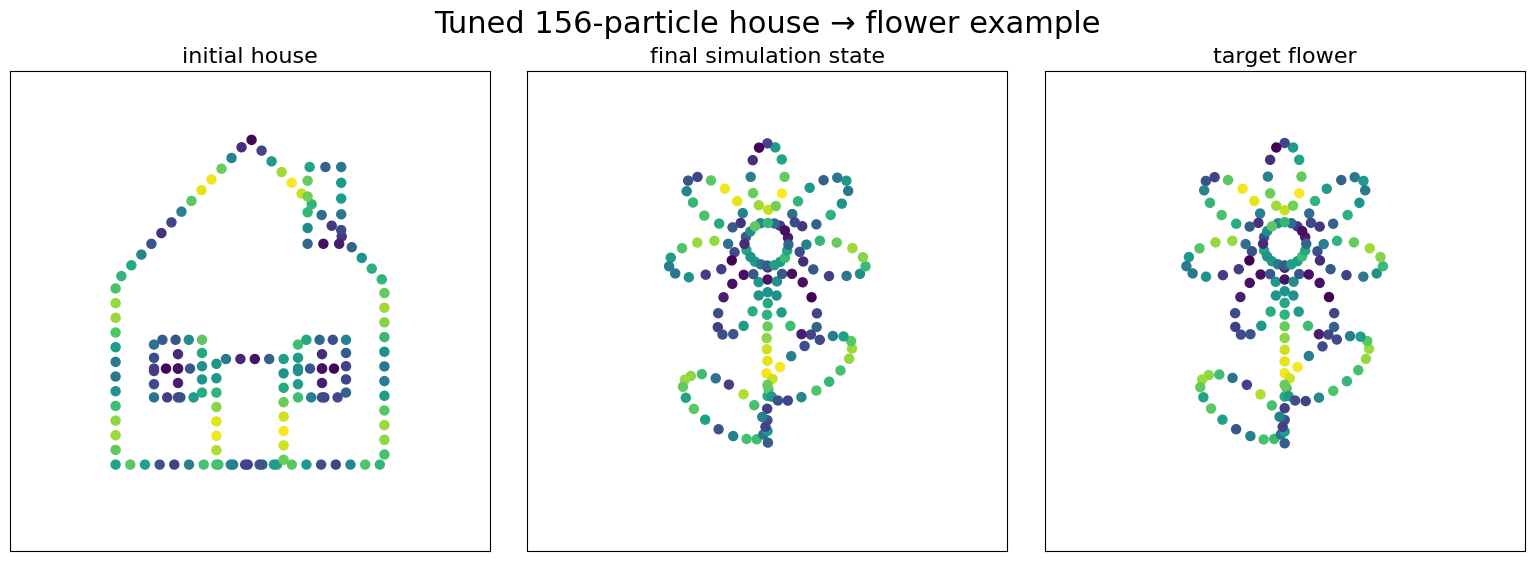

In [14]:
import matplotlib.pyplot as plt

final_positions = sim.positions[-1]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.5), constrained_layout=True)
panel_titles = ["initial house", "final simulation state", "target flower"]
panel_points = [house_points, final_positions, target_positions]

for ax, title, pts in zip(axes, panel_titles, panel_points):
    ax.scatter(pts[:, 0], pts[:, 1], c=masses, cmap="viridis", s=42)
    ax.set_title(title, fontsize=16)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(
    "Tuned 156-particle house → flower example",
    fontsize=22,
)
plt.show()